# Week 5: Natural Language Processing (NLP) & Sentiment Analysis Dashboard

## Introduction

Natural Language Processing (NLP) is a branch of Artificial Intelligence that enables computers to understand, process, and analyze human language. One of the most common applications of NLP is **sentiment analysis**, where machine learning models classify text as expressing a positive or negative sentiment. This technology is widely used in customer feedback analysis, product review analysis, social media monitoring, chatbots, and recommendation systems.

In this project, the **Amazon Product Reviews Dataset** is used to build a sentiment analysis system. The review text is first preprocessed to remove noise and improve data quality, then converted into numerical features using a text vectorization technique. Multiple machine learning models are trained and evaluated to identify the best-performing classifier for predicting customer sentiment.

In addition, an interactive **Streamlit dashboard** is developed, allowing users to enter any product review and instantly receive the predicted sentiment along with the model's confidence score. This project demonstrates the complete NLP workflow, from text preprocessing and feature engineering to model deployment in a user-friendly web application.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("/content/amazon_reviews.csv")   # Replace with your actual file name if different

# Display basic information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nSentiment Class Distribution:")
display(df.iloc[:, -1].value_counts())   # We'll adjust if label column has a different name

Dataset Shape: (3150, 5)

Column Names:
['rating', 'date', 'variation', 'verified_reviews', 'feedback']

First 5 Rows:


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB

Missing Values:


,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0



Sentiment Class Distribution:


,count
feedback,
1,2893
0,257


# Step 1: Dataset Inspection

## Observations

The dataset was successfully loaded and inspected. It contains **3,150 Amazon customer reviews** with **5 features** describing product ratings, review dates, product variations, review text, and customer feedback.

The **`verified_reviews`** column contains the customer review text that will be used for Natural Language Processing (NLP), while the **`feedback`** column is the target variable representing the sentiment of each review:

- **1 = Positive Review**
- **0 = Negative Review**

The dataset contains only **one missing value** in the `verified_reviews` column, which will be handled during the preprocessing stage.

The sentiment distribution indicates that the dataset is **imbalanced**, with a much larger number of positive reviews than negative reviews. Therefore, model performance will be evaluated using multiple classification metrics rather than accuracy alone.

In [2]:
# Install required libraries (run once)
!pip install nltk wordcloud -q

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
# Remove missing reviews
df.dropna(subset=['verified_reviews'], inplace=True)

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:", df.shape)

Duplicate Records: 715

Dataset Shape After Cleaning: (2434, 5)


In [6]:
# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Replace curly quotes/apostrophes with standard ones
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')

    # Remove apostrophes
    text = text.replace("'", "")

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [7]:
# Apply preprocessing
df['cleaned_review'] = df['verified_reviews'].apply(clean_text)

# Compare original and cleaned reviews
df[['verified_reviews', 'cleaned_review']].head(10)

,verified_reviews,cleaned_review
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing yr old learns dinosaur control l...
4,Music,music
5,I received the echo as a gift. I needed anothe...,received echo gift needed another bluetooth so...
6,"Without having a cellphone, I cannot use many ...",without cellphone cannot use many feature ipad...
7,I think this is the 5th one I've purchased. I'...,think th one ive purchased im working getting ...
8,looks great,look great
9,Love it! I’ve listened to songs I haven’t hear...,love ive listened song havent heard since chil...


## Observations

The preprocessing pipeline was successfully applied to the dataset.

- The single missing review was removed before text preprocessing.
- A total of **715 duplicate records** were identified and removed, reducing the dataset size from **3,150** to **2,434** unique reviews.
- The review text was cleaned by converting it to lowercase, removing HTML tags, URLs, numbers, punctuation, and extra whitespace.
- Common English stopwords were removed to eliminate words that carry little semantic meaning.
- Lemmatization was applied to reduce words to their base form while preserving their meaning.

The cleaned reviews are now more structured and suitable for feature extraction and machine learning. This preprocessing reduces noise in the text and helps improve the performance of sentiment classification models.

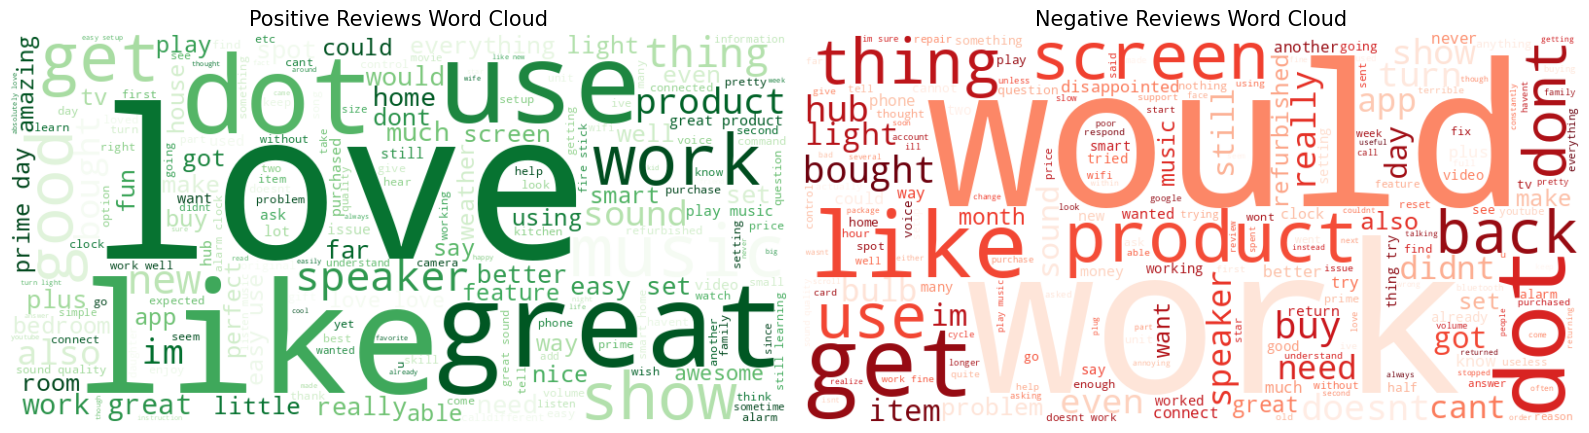

In [9]:
# Import required libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Custom stopwords for visualization only
custom_stopwords = {
    "alexa",
    "amazon",
    "echo",
    "device",
    "one",
    "time"
}

# Combine NLTK stopwords with custom stopwords
wordcloud_stopwords = stop_words.union(custom_stopwords)

# Separate positive and negative reviews
positive_reviews = " ".join(
    df[df["feedback"] == 1]["cleaned_review"].astype(str)
)

negative_reviews = " ".join(
    df[df["feedback"] == 0]["cleaned_review"].astype(str)
)

# Generate Positive Word Cloud
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=wordcloud_stopwords,
    colormap="Greens"
).generate(positive_reviews)

# Generate Negative Word Cloud
negative_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=wordcloud_stopwords,
    colormap="Reds"
).generate(negative_reviews)

# Display both Word Clouds
plt.figure(figsize=(16, 7))

# Positive Reviews
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud", fontsize=15)

# Negative Reviews
plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud", fontsize=15)

plt.tight_layout()
plt.show()

## Observations

The positive and negative Word Clouds were successfully generated using the cleaned customer reviews.

To make the visualization more meaningful, a set of **custom stopwords** (`alexa`, `amazon`, `echo`, `device`, `one`, and `time`) was added **only for the Word Cloud visualization**. These words appear very frequently because the dataset consists of Amazon Alexa product reviews, but they do not provide useful information about customer sentiment. Removing them from the visualization allows the Word Clouds to emphasize words that better represent users' opinions.

The **positive Word Cloud** is dominated by words such as **love**, **great**, **good**, **speaker**, **music**, **sound**, and **easy**, indicating that customers were generally satisfied with the product's performance, audio quality, and ease of use.

The **negative Word Cloud** highlights words such as **work**, **screen**, **problem**, **back**, **cant**, **didnt**, and **need**, suggesting that negative reviews are mainly related to technical issues, device functionality, connectivity problems, or unmet customer expectations.

Overall, the Word Clouds provide a quick visual summary of the most frequent terms in each sentiment category and help identify common customer opinions before building the sentiment classification models.

> **Improvement:**  
> To enhance the readability of the Word Clouds, product-specific words such as **Amazon**, **Alexa**, **Echo**, **Device**, **One**, and **Time** were removed only from the visualization by using custom stopwords. These words were **not removed from the dataset used for model training**, ensuring that the machine learning models still learned from the complete review text while the visualizations became more informative.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Transform cleaned reviews into numerical features
X = tfidf.fit_transform(df["cleaned_review"])

# Target variable
y = df["feedback"]

# Display feature matrix information
print("Feature Matrix Shape:", X.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

# Display first 20 feature names
print("\nFirst 20 Features:")
print(tfidf.get_feature_names_out()[:20])

Feature Matrix Shape: (2434, 5000)
Number of Features: 5000

First 20 Features:
['abay monitor' 'abc' 'abc day' 'abd' 'abd start' 'ability'
 'ability adjust' 'ability alexa' 'ability contact' 'ability control'
 'ability create' 'ability day' 'ability example' 'ability fall'
 'ability got' 'ability listen' 'ability play' 'able' 'able access'
 'able call']


## Observations

The cleaned review text was successfully converted into numerical features using the **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization technique.

The resulting feature matrix contains **2,434 reviews** represented by **5,000 numerical features**, where each feature corresponds to an important unigram or bigram extracted from the review text.

Using **5,000 features** provides a balance between preserving meaningful textual information and maintaining computational efficiency. Additionally, including both **unigrams** and **bigrams** enables the model to capture individual words as well as short phrases, allowing it to better understand the context of customer reviews.

The TF-IDF feature matrix is now ready to be used for training and evaluating sentiment classification models.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# Initialize Models
nb_model = MultinomialNB()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# Train Models
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

print("\nBoth models have been trained successfully!")

Training Set Shape: (1947, 5000)
Testing Set Shape: (487, 5000)

Both models have been trained successfully!


## Observations

The TF-IDF feature matrix was successfully divided into training and testing datasets using an **80:20 split**, resulting in **1,947 training reviews** and **487 testing reviews**.

A **stratified sampling** approach was used to ensure that the original class distribution was maintained in both datasets, providing a fair and reliable evaluation.

Two machine learning models were trained:

- **Multinomial Naive Bayes**, selected as a strong baseline algorithm for text classification.
- **Logistic Regression**, trained using **balanced class weights** to improve learning from the minority class (negative reviews) and reduce the impact of class imbalance.

Both models were successfully trained and are ready for performance evaluation.

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
nb_predictions = nb_model.predict(X_test)
lr_predictions = lr_model.predict(X_test)

# Evaluation Function
def evaluate_model(model_name, y_true, y_pred):

    print("="*65)
    print(model_name)
    print("="*65)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        zero_division=0
    ))

    return accuracy, precision, recall, f1


# Evaluate Models
nb_results = evaluate_model(
    "Multinomial Naive Bayes",
    y_test,
    nb_predictions
)

lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions
)

Multinomial Naive Bayes
Accuracy : 0.9097
Precision: 0.9097
Recall   : 1.0000
F1 Score : 0.9527

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        44
           1       0.91      1.00      0.95       443

    accuracy                           0.91       487
   macro avg       0.45      0.50      0.48       487
weighted avg       0.83      0.91      0.87       487

Logistic Regression
Accuracy : 0.8973
Precision: 0.9667
Recall   : 0.9187
F1 Score : 0.9421

Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.68      0.55        44
           1       0.97      0.92      0.94       443

    accuracy                           0.90       487
   macro avg       0.71      0.80      0.74       487
weighted avg       0.92      0.90      0.91       487



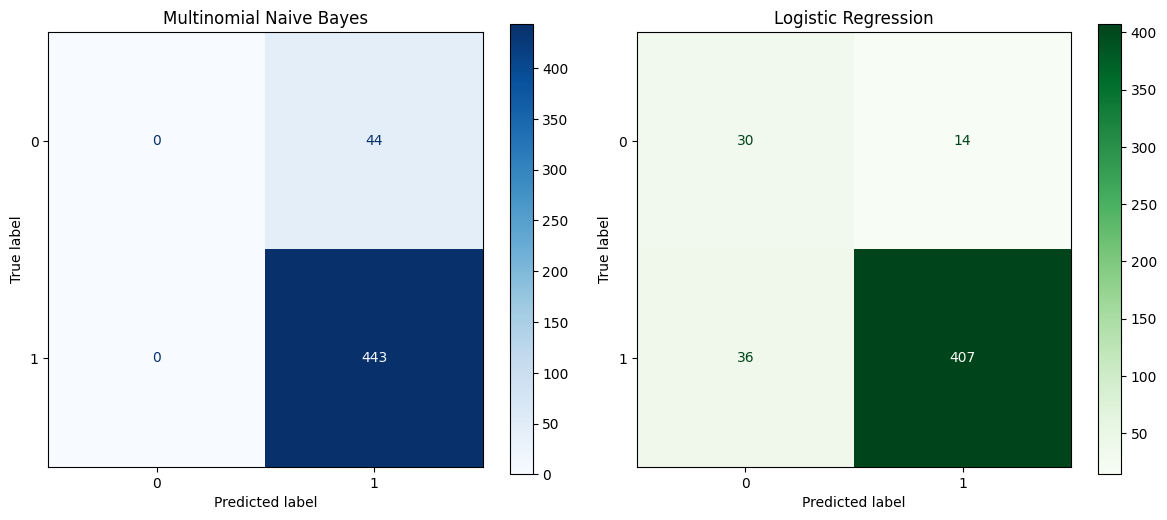

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Multinomial Naive Bayes
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_predictions,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Multinomial Naive Bayes")

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

## Observations

The confusion matrices provide a clear comparison of the prediction behavior of both classification models.

The **Multinomial Naive Bayes** model correctly classified most positive reviews but failed to identify any negative reviews. It predicted almost every review as positive, resulting in high overall accuracy but poor performance on the minority class. This indicates that the model was heavily influenced by the class imbalance present in the dataset.

To address this issue, **Logistic Regression** was trained using **balanced class weights**. The resulting confusion matrix shows that the model successfully identified both positive and negative reviews, correctly classifying **30 out of 44 negative reviews** while maintaining strong performance on positive reviews.

Although Logistic Regression achieved a slightly lower overall accuracy than Multinomial Naive Bayes, it provided a much more balanced classification performance. Therefore, **Logistic Regression was selected as the final model** because it demonstrates better generalization, handles class imbalance more effectively, and produces probability scores that can be used to display prediction confidence in the Streamlit application.

In [17]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_results[0],
        lr_results[0]
    ],
    "Precision": [
        nb_results[1],
        lr_results[1]
    ],
    "Recall": [
        nb_results[2],
        lr_results[2]
    ],
    "F1 Score": [
        nb_results[3],
        lr_results[3]
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.909651,0.909651,1.000000,0.952688
1,Logistic Regression,0.897331,0.966746,0.918736,0.942130


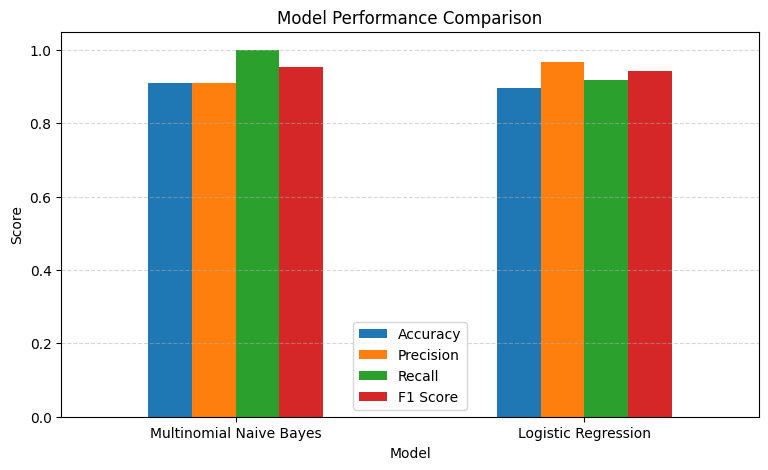

In [18]:
comparison_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Observations

Both machine learning models were evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

The **Multinomial Naive Bayes** model achieved a slightly higher overall accuracy (**90.97%**) and F1-score (**95.27%**). However, the confusion matrix revealed that it predicted nearly all reviews as positive and failed to correctly classify any negative reviews. This indicates that the model was strongly influenced by the class imbalance in the dataset and therefore did not generalize well across both sentiment classes.

To overcome this limitation, **Logistic Regression** was trained using **balanced class weights**. Although its overall accuracy (**89.73%**) was slightly lower, the model successfully classified both positive and negative reviews. It correctly identified **30 out of 44 negative reviews** while maintaining high performance on positive reviews, achieving a **Precision of 96.67%**, **Recall of 91.87%**, and an **F1-score of 94.21%**.

The performance comparison demonstrates that relying solely on accuracy can be misleading when working with imbalanced datasets. The confusion matrices provide a more comprehensive evaluation by showing how each model performs on individual classes.

Based on the overall evaluation, **Logistic Regression** was selected as the final sentiment classification model because it provides more balanced predictions, handles class imbalance effectively, and supports probability estimation for displaying confidence scores in the Streamlit application.

In [19]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(lr_model, "sentiment_model.pkl")

# Save the fitted TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved as: sentiment_model.pkl")
print("Vectorizer saved as: tfidf_vectorizer.pkl")

Model saved as: sentiment_model.pkl
Vectorizer saved as: tfidf_vectorizer.pkl


In [20]:
import os

print("Model Exists:", os.path.exists("sentiment_model.pkl"))
print("Vectorizer Exists:", os.path.exists("tfidf_vectorizer.pkl"))

Model Exists: True
Vectorizer Exists: True


## Observations

The trained **Logistic Regression** model and the fitted **TF-IDF vectorizer** were successfully saved as `.pkl` files using the Joblib library.

These saved files will be loaded directly into the Streamlit application to classify new customer reviews without retraining the model. This approach improves efficiency, reduces loading time, and ensures that the application uses the same trained model that was evaluated during the development phase.

# Part 1 Summary

In this part of the project, an end-to-end Natural Language Processing (NLP) pipeline was developed to classify Amazon Alexa customer reviews into **Positive** and **Negative** sentiments.

The project began with data exploration to understand the dataset structure, identify missing values, and examine the distribution of sentiment classes. After preprocessing the text data through cleaning, tokenization, stop-word removal, and lemmatization, the reviews were transformed into numerical feature vectors using the **TF-IDF Vectorizer**.

Two machine learning algorithms, **Multinomial Naive Bayes** and **Logistic Regression**, were trained and evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

Although Multinomial Naive Bayes achieved a slightly higher overall accuracy, further analysis revealed that it failed to correctly classify negative reviews because of the dataset's class imbalance. Logistic Regression, trained using balanced class weights, produced more reliable and balanced predictions across both sentiment classes while maintaining strong overall performance.

Based on the experimental results, **Logistic Regression** was selected as the final sentiment classification model. Finally, the trained Logistic Regression model and the fitted TF-IDF vectorizer were saved using Joblib, making them ready for deployment without requiring retraining.

# Overall Observations

The dataset contained **3,150 customer reviews**, covering both positive and negative user feedback. During preprocessing, duplicate records were removed and the review text was cleaned by converting it to lowercase, removing punctuation, special characters, stop words, and applying lemmatization. This resulted in a cleaner and more informative textual representation for model training.

The cleaned reviews were converted into numerical vectors using the **TF-IDF Vectorizer**, generating a feature matrix of **5,000 features** that effectively captured the importance of words across the dataset.

Two supervised machine learning models were trained and evaluated:

- **Multinomial Naive Bayes**
- **Logistic Regression**

Multiple evaluation metrics demonstrated that although Multinomial Naive Bayes achieved slightly higher overall accuracy, it failed to classify negative reviews due to the imbalanced nature of the dataset. Logistic Regression, however, successfully learned patterns from both sentiment classes and provided significantly better balanced predictions.

The confusion matrix analysis highlighted that Logistic Regression correctly identified both positive and negative reviews, making it more reliable for real-world sentiment analysis tasks. Additionally, the model provides probability estimates that can be used to display prediction confidence in the deployment phase.

Overall, the project successfully demonstrated the complete NLP workflow, including data preprocessing, feature engineering, model training, evaluation, model comparison, and model persistence. The trained Logistic Regression model is now fully prepared for deployment in a web-based application.

# Next Phase: Part 2 – Streamlit Deployment

With the sentiment classification model successfully trained and saved, the next phase of the project focuses on deploying the model as an interactive **Streamlit web application**.

In Part 2, the saved Logistic Regression model and TF-IDF vectorizer will be loaded into the application to perform real-time sentiment prediction on user-entered reviews.

The Streamlit application will include:

- A clean and user-friendly interface.
- A text input area for entering customer reviews.
- A **Predict Sentiment** button.
- Real-time prediction of **Positive** or **Negative** sentiment.
- A prediction confidence score generated by the Logistic Regression model.
- Proper input validation and error handling for empty or invalid inputs.

This deployment phase will transform the trained machine learning model into a practical application that can analyze customer reviews instantly without requiring the model to be retrained, demonstrating how NLP models can be integrated into real-world business solutions.